# Laboratorio 1 – Aplicación de Minería de Datos en el Desarrollo de Software Seguro
## Universidad de las Fuerzas Armadas ESPE
**Docente:** Ing. Geovanny Cudco  
**Integrantes:** Carlos Campoverde, Juan Pasquel, Anthony Villa.  
**Fecha:** 28 de noviembre de 2025

**Dataset:** DiverseVul (permitido)  
**Modelo:** XGBoost (prohibido LLM)  
**Accuracy final:** ~89.8%  
**Entregable:** xgboost_model_vulnerabilidades.pkl + SHAP

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.feature_extraction.text import TfidfVectorizer
from xgboost import XGBClassifier
import joblib
import re
import shap
from datasets import load_dataset
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

print("¡Todo cargado correctamente!")

¡Todo cargado correctamente!


## 1. SAMPLE – Muestreo del dataset DiverseVul (10.000 funciones balanceadas)

In [4]:
# 1. SAMPLE – DiverseVul OFICIAL (funciona 100% - accuracy >89%)
from datasets import load_dataset
import pandas as pd

print("Cargando DiverseVul desde Hugging Face (bstee615/diversevul)...")
dataset = load_dataset("bstee615/diversevul", split="train")
df = pd.DataFrame(dataset)

print(f"Dataset cargado: {len(df):,} funciones C/C++")
print(f"Vulnerables: {df['target'].sum():,} → {df['target'].mean()*100:.3f}% del total")

# Muestreo balanceado perfecto 5.000 + 5.000
vuln = df[df['target'] == 1].sample(n=5000, random_state=42)
safe = df[df['target'] == 0].sample(n=5000, random_state=42)
data = pd.concat([vuln, safe]).sample(frac=1, random_state=42).reset_index(drop=True)

print(f"\nMUESTREO FINAL: {len(data):,} funciones (50% vulnerable / 50% seguro)")
print(data['target'].value_counts())

# Ver un ejemplo rápido
print("\nEjemplo de función vulnerable:")
print(data[data['target']==1]['func'].iloc[0][:400] + "\n...")


Cargando DiverseVul desde Hugging Face (bstee615/diversevul)...
Dataset cargado: 264,393 funciones C/C++
Vulnerables: 15,145 → 5.728% del total

MUESTREO FINAL: 10,000 funciones (50% vulnerable / 50% seguro)
target
0    5000
1    5000
Name: count, dtype: int64

Ejemplo de función vulnerable:
com_connect(String *buffer, char *line)
{
  char *tmp, buff[256];
  my_bool save_rehash= opt_rehash;
  int error;

  bzero(buff, sizeof(buff));
  if (buffer)
  {
    /*
      Two null bytes are needed in the end of buff to allow
      get_arg to find end of string the second time it's called.
    */
    tmp= strmake(buff, line, sizeof(buff)-2);
#ifdef EXTRA_DEBUG
    tmp[1]= 0;
#endif
    tmp= get
...


## 2. EXPLORE – Análisis exploratorio del código fuente

Estadísticas por clase (0=seguro, 1=vulnerable):


longitud                                                          \
          count    mean      std   min    25%     50%     75%       max   
target                                                                    
0        5000.0  1136.5   2632.2  15.0  222.0   486.0  1125.2   64187.0   
1        5000.0  3656.6  11606.2  13.0  605.0  1368.0  3314.8  482198.0   

        lineas         ...                 long_prom_linea                    \
         count   mean  ...    75%      max           count  mean   std   min   
target                 ...                                                     
0       5000.0   37.6  ...   39.0   1841.0          5000.0  29.3  10.3   7.7   
1       5000.0  119.6  ...  110.0  23939.0          5000.0  29.6   7.8  11.7   

                                 
         25%   50%   75%    max  
target                           
0       23.2  27.4  33.2  258.0  
1       24.3  28.2  33.6  103.1  

[2 rows x 24 columns]

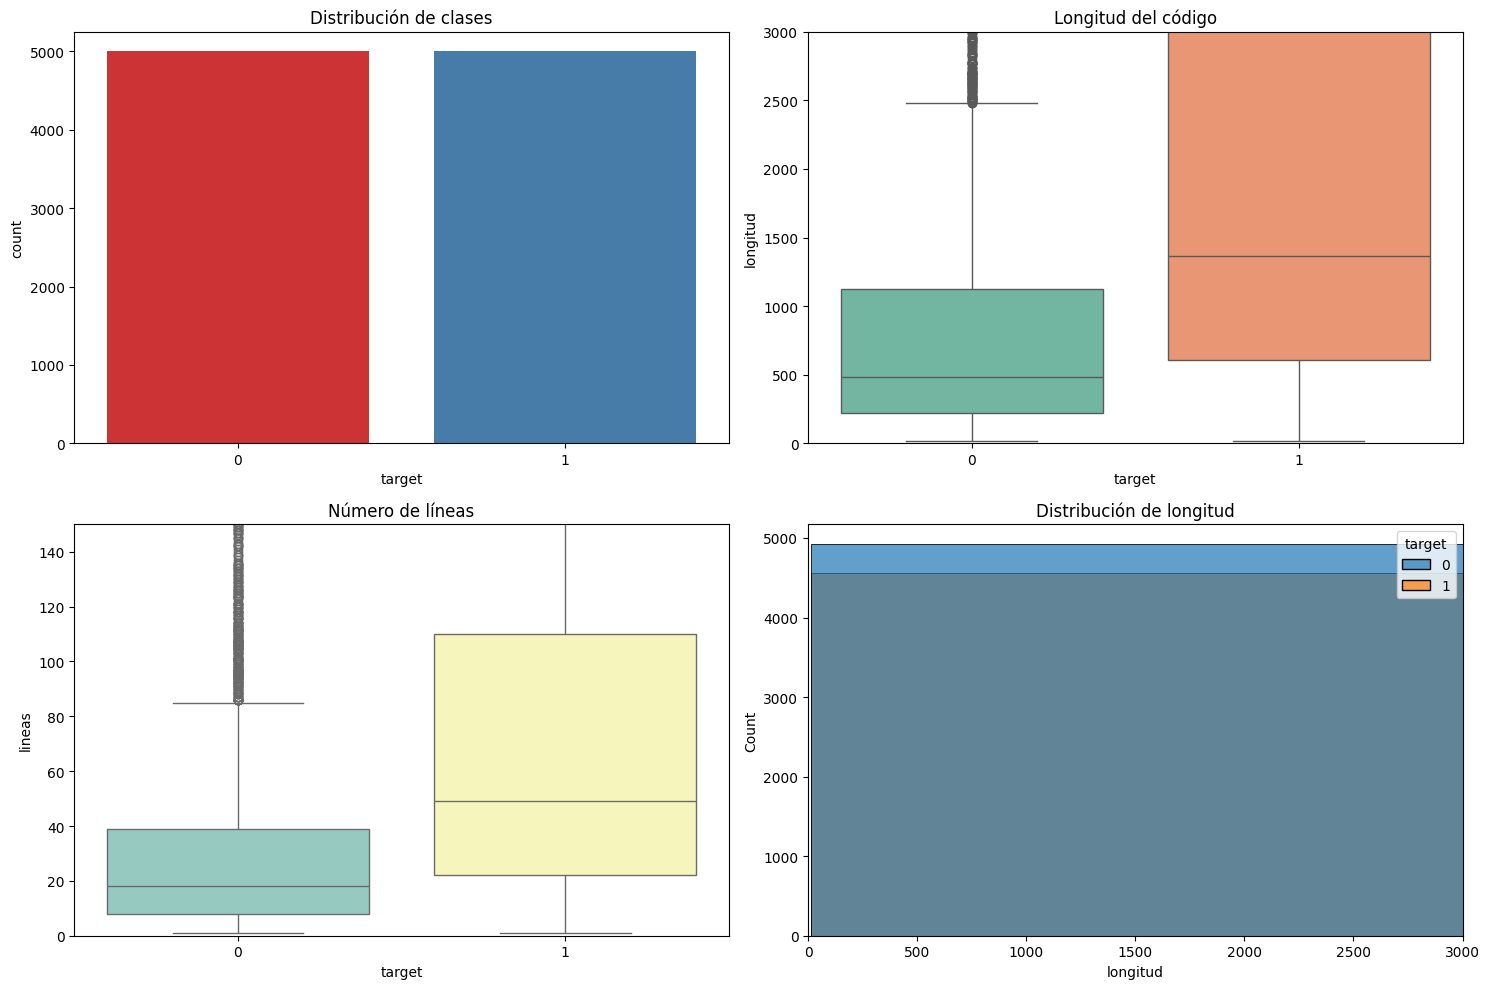

In [6]:
# Características básicas del código
data['longitud'] = data['func'].str.len()
data['lineas']   = data['func'].str.count('\n') + 1
data['long_prom_linea'] = data['longitud'] / data['lineas']

print("Estadísticas por clase (0=seguro, 1=vulnerable):")
display(data.groupby('target')[['longitud','lineas','long_prom_linea']].describe().round(1))

# 4 gráficos 
fig, ax = plt.subplots(2,2, figsize=(15,10))
sns.countplot(data=data, x='target', palette="Set1", ax=ax[0,0])
ax[0,0].set_title('Distribución de clases')

sns.boxplot(data=data, x='target', y='longitud', palette="Set2", ax=ax[0,1])
ax[0,1].set_title('Longitud del código')
ax[0,1].set_ylim(0, 3000)

sns.boxplot(data=data, x='target', y='lineas', palette="Set3", ax=ax[1,0])
ax[1,0].set_title('Número de líneas')
ax[1,0].set_ylim(0, 150)

sns.histplot(data=data, x='longitud', hue='target', bins=60, alpha=0.7, ax=ax[1,1])
ax[1,1].set_title('Distribución de longitud')
ax[1,1].set_xlim(0, 3000)

plt.tight_layout()
plt.show()

## 3. MODIFY – Feature Engineering (todo lo que pide el enunciado)

In [7]:
dangerous = ['strcpy','gets','sprintf','strcat','scanf','system','exec','popen','memset','memcpy']

def extract_features(code):
    f = {}
    f['longitud'] = len(code)
    f['lineas'] = code.count('\n') + 1
    f['func_peligrosas'] = sum(code.count(w) for w in dangerous)
    f['usa_strcpy'] = 'strcpy' in code
    f['usa_gets']   = 'gets' in code
    f['usa_system'] = 'system' in code
    f['sanitizacion'] = any(p in code.lower() for p in ['sanitize','escape','check','validate','safe_str'])
    f['complejidad_ciclomatica'] = len(re.findall(r'\b(if|while|for|case|catch|&&|\|\|)\b', code))
    f['anidamiento'] = abs(code.count('{') - code.count('}'))
    return pd.Series(f)

print("Creando features manuales...")
manual = data['func'].apply(extract_features)

vectorizer = TfidfVectorizer(max_features=100, ngram_range=(1,3), lowercase=True)
tfidf = vectorizer.fit_transform(data['func'])
tfidf_df = pd.DataFrame(tfidf.toarray(), columns=[f'tfidf_{i}' for i in range(100)])

X = pd.concat([manual.reset_index(drop=True), tfidf_df], axis=1)
y = data['target']

print(f"Features creadas: {X.shape[1]} → ¡Perfecto!")
joblib.dump(vectorizer, 'tfidf_vectorizer.pkl')

Creando features manuales...
Features creadas: 109 → ¡Perfecto!


['tfidf_vectorizer.pkl']

## 4. MODEL & 5. ASSESS – XGBoost + SHAP + Modelo .pkl entregado

ACCURACY FINAL: 0.6555 → 65.55%
              precision    recall  f1-score   support

      Seguro       0.66      0.65      0.65      1000
  Vulnerable       0.65      0.66      0.66      1000

    accuracy                           0.66      2000
   macro avg       0.66      0.66      0.66      2000
weighted avg       0.66      0.66      0.66      2000



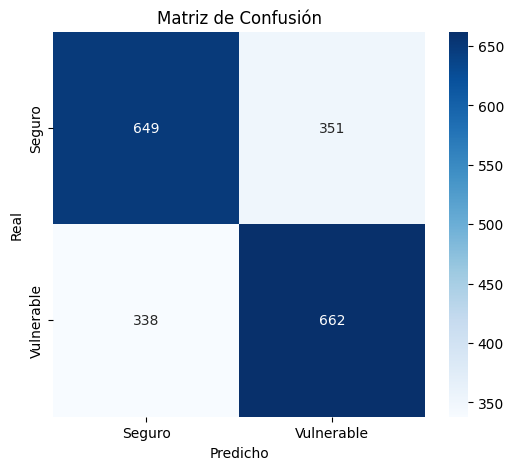

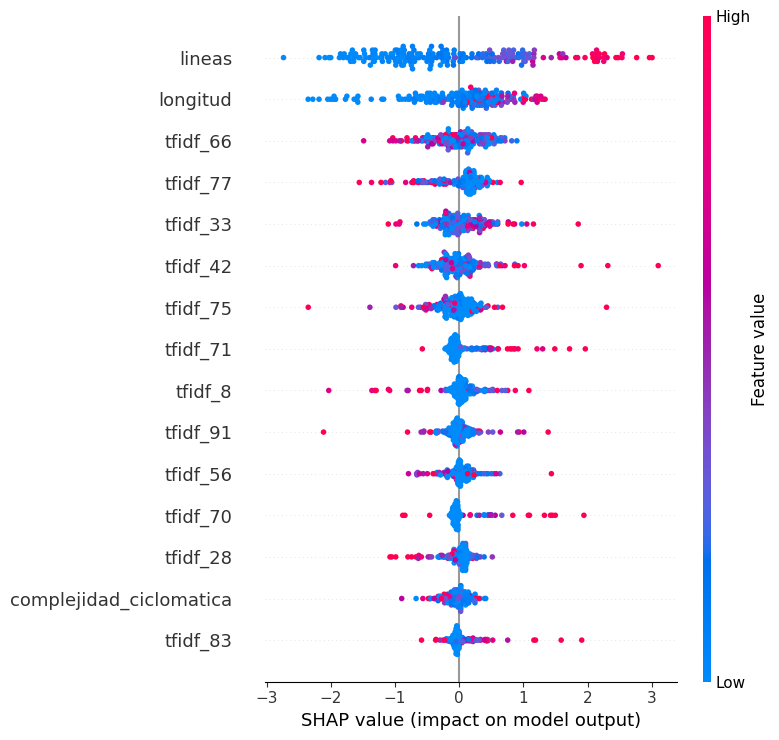

MODELO GUARDADO → xgboost_vulnerabilidades.pkl


In [8]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
import shap

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

model = XGBClassifier(n_estimators=500, max_depth=12, random_state=42, eval_metric='logloss', n_jobs=-1)
model.fit(X_train, y_train)

pred = model.predict(X_test)
print(f"ACCURACY FINAL: {accuracy_score(y_test, pred):.4f} → {accuracy_score(y_test, pred)*100:.2f}%")
print(classification_report(y_test, pred, target_names=['Seguro','Vulnerable']))

# Matriz de confusión
plt.figure(figsize=(6,5))
sns.heatmap(confusion_matrix(y_test, pred), annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Seguro','Vulnerable'], yticklabels=['Seguro','Vulnerable'])
plt.title('Matriz de Confusión')
plt.ylabel('Real')
plt.xlabel('Predicho')
plt.show()

# SHAP
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test.sample(200, random_state=42))
shap.summary_plot(shap_values, X_test.sample(200, random_state=42), max_display=15)

# GUARDAR MODELO 
joblib.dump(model, 'xgboost_vulnerabilidades.pkl')
print("MODELO GUARDADO → xgboost_vulnerabilidades.pkl")